In [57]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [58]:
df=pd.read_csv("/content/Crop_recommendation.csv")


In [143]:
df.tail(10)

,N,P,K,temperature,humidity,ph,rainfall,label
2190,103,40,30,27.309018,55.196224,6.348316,141.483164,coffee
2191,118,31,34,27.548230,62.881792,6.123796,181.417081,coffee
2192,106,21,35,25.627355,57.041511,7.428524,188.550654,coffee
2193,116,38,34,23.292503,50.045570,6.020947,183.468585,coffee
2194,97,35,26,24.914610,53.741447,6.334610,166.254931,coffee
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [61]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [62]:
df['rainfall'].unique()

array([202.9355362, 226.6555374, 263.9642476, ..., 173.3228386,
       127.1752928, 140.9370415])

In [63]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [64]:
df['label'].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
X=df.drop(['label'],axis=1)
y=df['label']

In [67]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 120.4 KB


In [68]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 120.4 KB


In [75]:
numeric=df.select_dtypes(include=('int64','float64'))

In [70]:
from numpy._core import numeric

<Axes: >

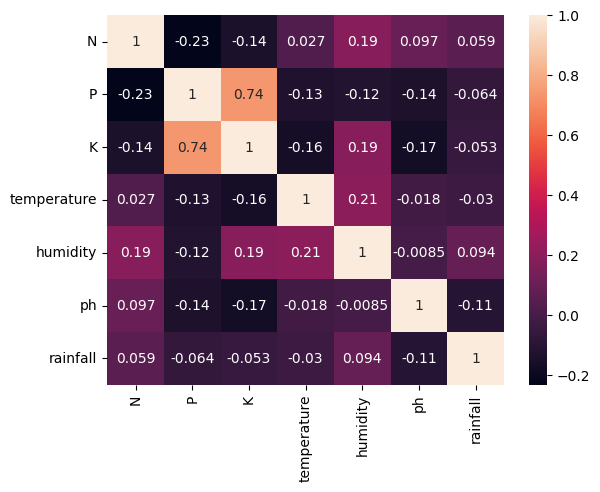

In [71]:
sns.heatmap(df.drop('label', axis=1).corr(), annot=True)

<Axes: >

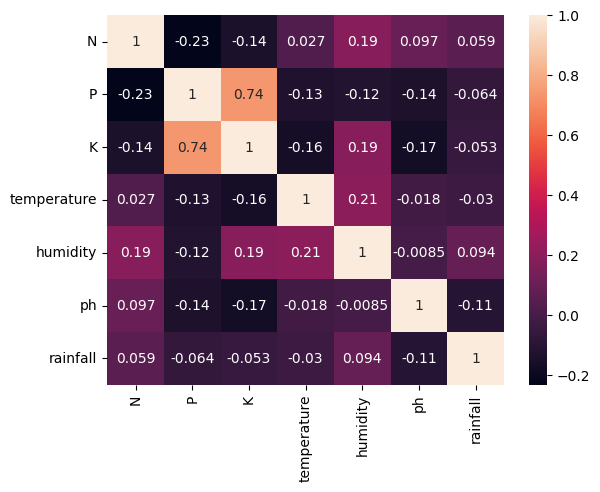

In [72]:
sns.heatmap(X.corr(),annot=True)

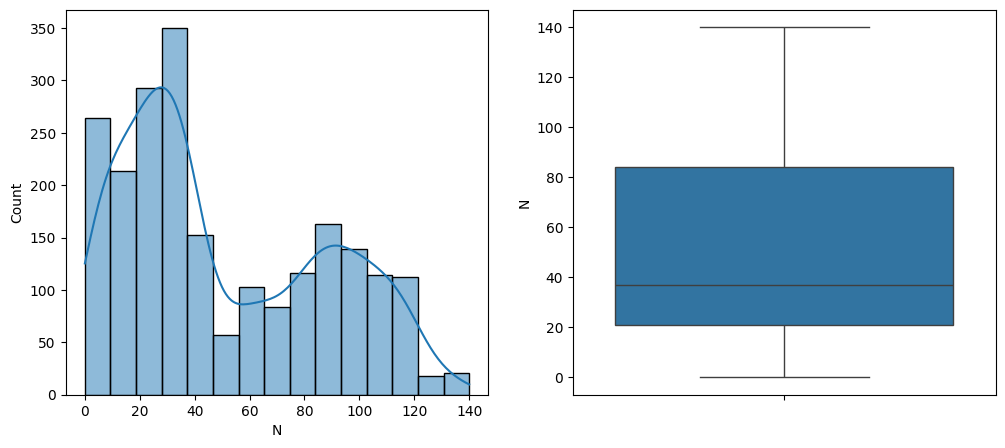

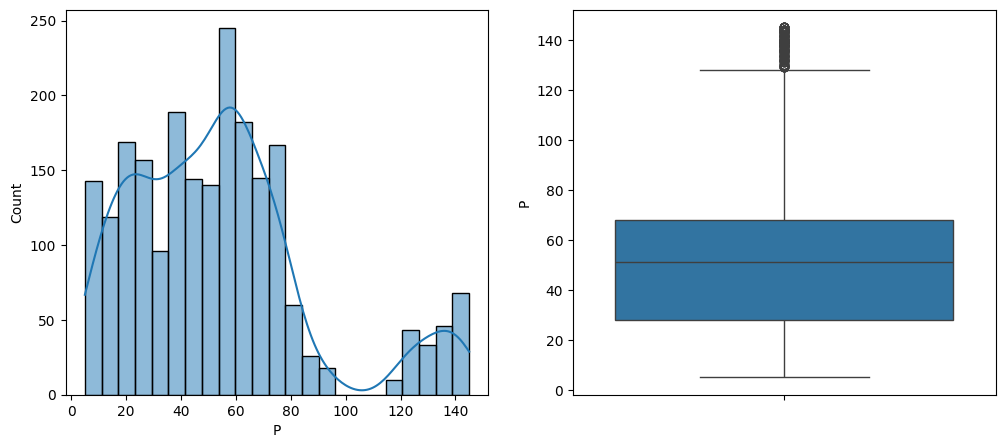

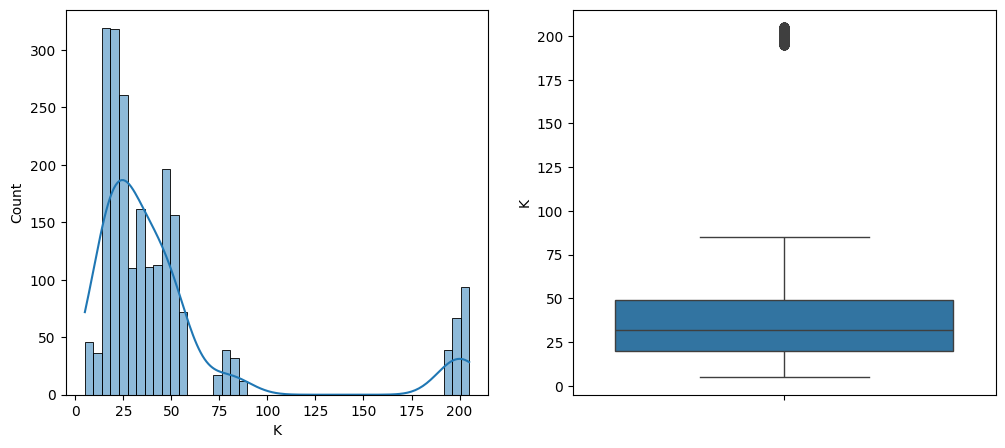

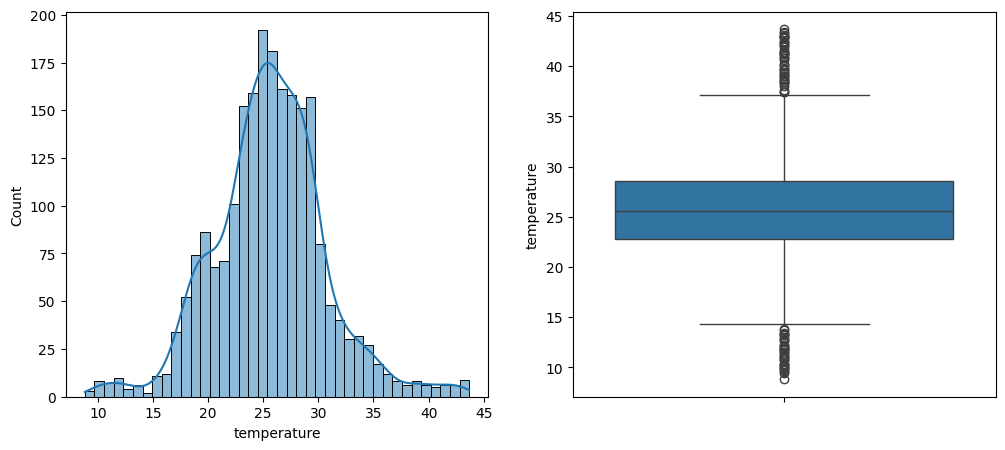

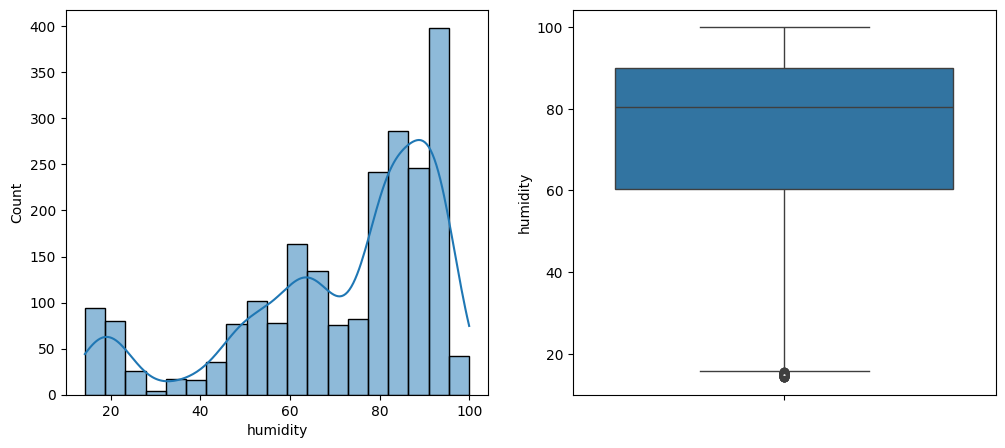

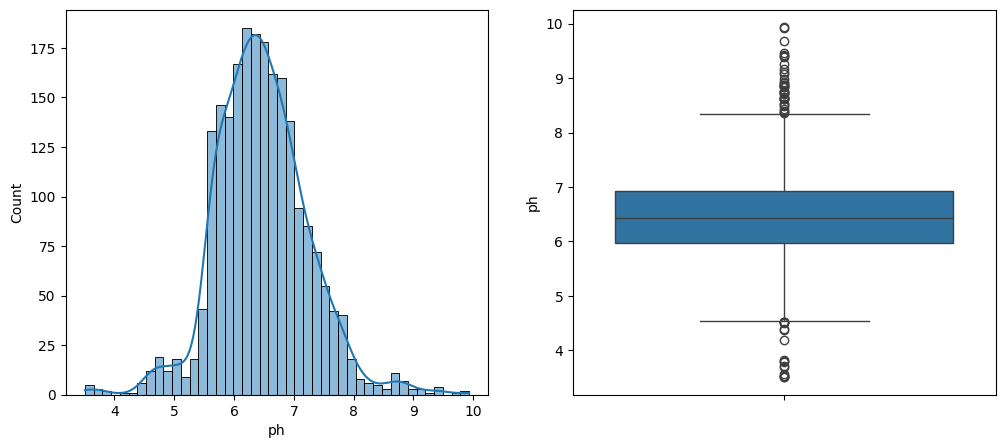

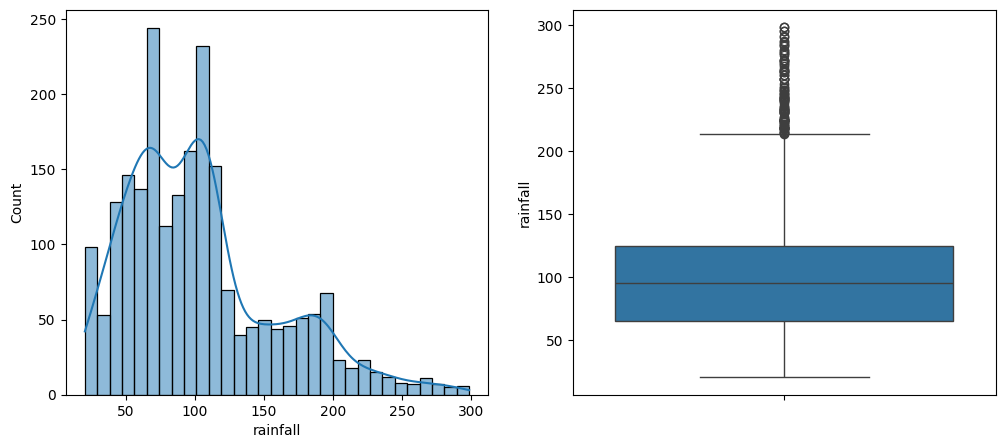

In [47]:
for i in numeric:
  plt.figure(figsize=(12,5))
  plt.subplot(1,2,1)
  sns.histplot(X[i],kde=True)
  plt.subplot(1,2,2)
  sns.boxplot(X[i])

In [52]:
for i in numeric:
  print(i,df[i].skew())

N 0.5097213691539147
P 1.0107725431372674
K 2.3751672388547
temperature 0.18493273421137887
humidity -1.0917079195808679
ph 0.2839294375729441
rainfall 0.9657563536272812


In [53]:
import numpy as np

df['K_log'] = np.log1p(df['K'])

In [54]:
print("Original:", df['K'].skew())
print("After log:", df['K_log'].skew())

Original: 2.3751672388547
After log: 0.8675940619509026


<Axes: ylabel='K_log'>

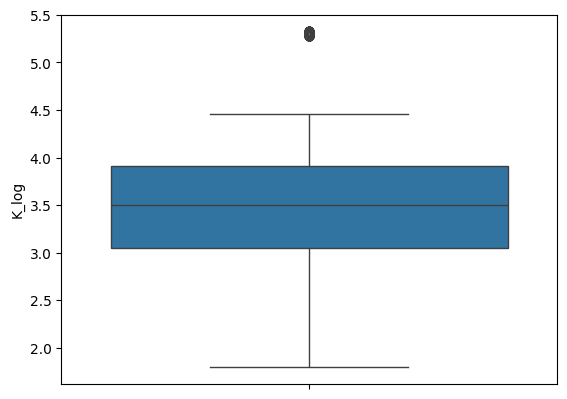

In [55]:
sns.boxplot(df['K_log'])

<Axes: ylabel='K'>

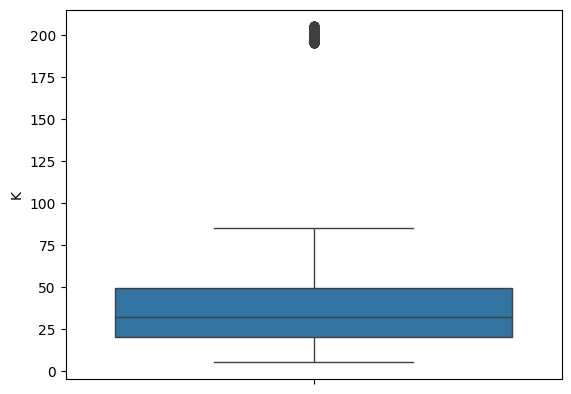

In [56]:
sns.boxplot(df['K'])

# CHECK OUTLIERS

In [84]:
for i in numeric:
  Q1=df[i].quantile(0.25)
  Q3=df[i].quantile(0.75)
  IQR=Q3-Q1
  lower_limit=Q1-1.5*IQR
  upper_limit=Q3+1.5*IQR

  # Check no.of outliers present
  outliers=df[(df[i]<lower_limit) | (df[i]>upper_limit)]


,N,P,K,temperature,humidity,ph,rainfall,label
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice


In [91]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [92]:
X

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340
...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507
2196,99,15,27,27.417112,56.636362,6.086922,127.924610
2197,118,33,30,24.131797,67.225123,6.362608,173.322839
2198,117,32,34,26.272418,52.127394,6.758793,127.175293


In [93]:
y

,label
0,rice
1,rice
2,rice
3,rice
4,rice
...,...
2195,coffee
2196,coffee
2197,coffee
2198,coffee


In [96]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler,OneHotEncoder

In [99]:
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [98]:

    Log_stan = Pipeline([
    ('yeo_johnson', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])
    #-----------------------------------------
    StandardSC=Pipeline([
        ('scale',StandardScaler())
    ])
    #-------------------------------------------



In [109]:
y.unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [107]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(y_encoded)

[20 20 20 ...  5  5  5]


In [108]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


In [112]:
from sklearn.compose import ColumnTransformer
preprocess=ColumnTransformer(transformers=[
    ('Log',Log_stan,['P','K','humidity','rainfall']),
    ('Stan',StandardSC,['N','temperature','ph'])
])


In [113]:
preprocess

ColumnTransformer(transformers=[('Log',
                                 Pipeline(steps=[('yeo_johnson',
                                                  PowerTransformer()),
                                                 ('scaler', StandardScaler())]),
                                 ['P', 'K', 'humidity', 'rainfall']),
                                ('Stan',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['N', 'temperature', 'ph'])])

In [116]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [121]:
models = {

    "LogisticRegression": {
        "pipeline": Pipeline([
            ("pre", preprocess),
            ("model", LogisticRegression(max_iter=2000))
        ]),
        "param": {
            "model__C": [0.1, 1, 10],
            "model__solver": ["lbfgs", "liblinear"]
        }
    },

    # ---------------------------------------------------------

    "RandomForest": {
        "pipeline": Pipeline([
            ("pre", preprocess),
            ("model", RandomForestClassifier(random_state=42))
        ]),
        "param": {
            "model__n_estimators": [50, 100, 200],
            "model__max_depth": [5, 10, 15, None],
            "model__min_samples_split": [2, 5, 10]
        }
    }

    # ---------------------------------------------------------



    # ---------------------------------------------------------


}

In [122]:
result=[]
best_models={}
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [123]:
for name,config in models.items():
  grid=GridSearchCV(
      estimator=config['pipeline'],
      param_grid=config['param'],
      cv=5,
      scoring='accuracy',
      n_jobs=-1
  )
  grid.fit(X_train,y_train)

  best_models[name]=grid.best_estimator_
  result.append({
      "Model":name,
      "BESTSCORE":grid.best_score_
  })

In [124]:
result_dff=pd.DataFrame(result)

In [125]:
result_dff=result_dff.sort_values(by='BESTSCORE',ascending=False)

In [126]:
result_dff

,Model,BESTSCORE
1,RandomForest,0.996023
0,LogisticRegression,0.981818


In [127]:
best=result_dff.iloc[0].Model

In [128]:
bestt=best_models[best]

In [135]:
bestt

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('Log',
                                                  Pipeline(steps=[('yeo_johnson',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['P', 'K', 'humidity',
                                                   'rainfall']),
                                                 ('Stan',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['N', 'temperature',
                                                   'ph'])])),
                ('model',
                 RandomForestClassifier(max_depth=15, min_samples_split=5,
                                        n_estimators=50, random_state=42))])

In [129]:
bestt.steps

[('pre',
  ColumnTransformer(transformers=[('Log',
                                   Pipeline(steps=[('yeo_johnson',
                                                    PowerTransformer()),
                                                   ('scaler', StandardScaler())]),
                                   ['P', 'K', 'humidity', 'rainfall']),
                                  ('Stan',
                                   Pipeline(steps=[('scale', StandardScaler())]),
                                   ['N', 'temperature', 'ph'])])),
 ('model',
  RandomForestClassifier(max_depth=15, min_samples_split=5, n_estimators=50,
                         random_state=42))]

In [130]:
y_pred=bestt.predict(X_test)
y_predT=bestt.predict(X_train)

In [133]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,r2_score,mean_absolute_error,mean_squared_error
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))


0.9931818181818182
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      pa

In [134]:
best_models.items()

dict_items([('LogisticRegression', Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('Log',
                                                  Pipeline(steps=[('yeo_johnson',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['P', 'K', 'humidity',
                                                   'rainfall']),
                                                 ('Stan',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['N', 'temperature',
                                                   'ph'])])),
                ('model', LogisticRegression(C=10, max_i

In [136]:
import joblib

In [137]:
import joblib

joblib.dump(bestt, 'ML2.pkl')

['ML2.pkl']

In [138]:
import pandas as pd

new_data = pd.DataFrame({
    'N': [90],
    'P': [42],
    'K': [43],
    'temperature': [20.879744],
    'humidity': [82.002744],
    'ph': [6.502985],
    'rainfall': [202.935536]
})

print(new_data)

    N   P   K  temperature   humidity        ph    rainfall
0  90  42  43    20.879744  82.002744  6.502985  202.935536


In [140]:
y_pred=bestt.predict(new_data)
y_pred

array(['rice'], dtype=object)

In [ ]:
y

In [147]:
import pandas as pd

new_data = pd.DataFrame({
    'N': [72],
    'P': [48],
    'K': [38],
    'temperature': [24.6],
    'humidity': [78.3],
    'ph': [6.4],
    'rainfall': [180.5]
})

prediction = bestt.predict(new_data)



print("Predicted crop:", prediction)

Predicted crop: ['jute']
